In [160]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [161]:
raw= pd.read_csv("../data/ecommerce_raw.csv")
df=raw.copy()

In [162]:
print("\n--- COLUMNS ---")
print(df.columns.tolist())


--- COLUMNS ---
['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Sales', 'Discount', 'Cost', 'Profit', 'Shipping_Cost', 'Delivery_Days', 'Region', 'State', 'City', 'Payment_Mode', 'Returned']


In [163]:
df['Category'].unique()
df['Category']=df['Category'].str.strip().str.title()
df['Category'].unique()
df['State'].unique()
df['State']=df['State'].str.strip().str.title()
df['State'].unique()




<StringArray>
[   'Maharashtra',      'Karnataka',          'Delhi',        'Gujarat',
    'West Bengal',      'Rajasthan',          'Assam', 'Madhya Pradesh',
     'Tamil Nadu',         'Kerala',  'Uttar Pradesh',         'Odisha',
      'Telangana',          'Bihar']
Length: 14, dtype: str

In [164]:
df.duplicated().sum()
df = df.drop_duplicates()
df.shape


(97965, 19)

In [165]:
df.dtypes
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.dtypes
df["Order_Date"].dt.year
df["Returned"] = df["Returned"].replace({"Y": "Yes", "N": "No"})
print(df["Returned"].unique())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [166]:
df.info
df[df['Quantity']<0]
df = df[-df['Quantity']<0]
(df['Quantity']<0).sum()
df[df['Sales']<0]
df = df[-df['Sales']<0]
(df['Sales']<0).sum()



np.int64(0)

In [167]:
df.isna().sum()
#df[df['City'].isna()].sample(10)
df.groupby("Customer_ID")["City"].nunique().max()
city_map = (df.dropna(subset=["City"])
              .groupby("Customer_ID")["City"]
              .first())
df["City"] = df["City"].fillna(df["Customer_ID"].map(city_map))
df["City"] = df["City"].fillna("Unknown")
df['City'].isna().sum()

np.int64(0)

In [168]:
df.groupby("Order_ID")["Payment_Mode"].nunique().max()
pay_map = (df.dropna(subset=["Payment_Mode"])
              .groupby("Order_ID")["Payment_Mode"]
              .first())
df["Payment_Mode"] = df["Payment_Mode"].fillna(df["Order_ID"].map(pay_map))
df["Payment_Mode"] = df["Payment_Mode"].fillna("Unknown")
df['Payment_Mode'].isna().sum()
df.isna().sum()

Order_ID           0
Order_Date         0
Customer_ID        0
Product_ID         0
Product_Name       0
Category           0
Sub_Category       0
Quantity           0
Sales              0
Discount         486
Cost               0
Profit             0
Shipping_Cost      0
Delivery_Days      0
Region             0
State              0
City               0
Payment_Mode       0
Returned           0
dtype: int64

In [169]:
df["Discount_Imputed"] = df["Discount"].isna()

typical = df.groupby("Sub_Category")["Discount"].agg(lambda s: s.mode().iloc[0])
df["Discount"] = df["Discount"].fillna(df["Sub_Category"].map(typical))
df.isna().sum()
df['Discount']

0        0.50
1        0.00
2        0.05
3        0.40
4        0.40
         ... 
98940    0.15
98941    0.00
98942    0.00
98943    0.00
98944    0.40
Name: Discount, Length: 97673, dtype: float64

In [170]:
print(df.isna().sum().sum())                  # 0, or only labelled "Unknown" values
print(df.duplicated().sum())                  # 0
print(df["Category"].nunique(), df["State"].nunique())   # 5 and 14
print(df["Returned"].unique())                # only Yes / No
print(df["Order_Date"].dtype)                 # datetime64
print((df["Quantity"] <= 0).sum(), (df["Sales"] <= 0).sum())   # 0 and 0

0
0
5 14
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
datetime64[us]
0 0


In [171]:
print("Nulls:", df.isna().sum().sum(), "PASS" if df.isna().sum().sum() == 0 else "FAIL")
print("Duplicates:", df.duplicated().sum(), "PASS" if df.duplicated().sum() == 0 else "FAIL")
print("Categories:", df["Category"].nunique(), "PASS" if df["Category"].nunique() == 5 else "FAIL")
print("States:", df["State"].nunique(), "PASS" if df["State"].nunique() == 14 else "FAIL")
print("Returned:", sorted(df["Returned"].unique()), "PASS" if set(df["Returned"].unique()) == {"Yes", "No"} else "FAIL")
print("Date type:", df["Order_Date"].dtype, "PASS" if "datetime" in str(df["Order_Date"].dtype) else "FAIL")
print("Quantity <= 0:", (df["Quantity"] <= 0).sum(), "PASS" if (df["Quantity"] <= 0).sum() == 0 else "FAIL")
print("Sales <= 0:", (df["Sales"] <= 0).sum(), "PASS" if (df["Sales"] <= 0).sum() == 0 else "FAIL")
print("Columns:", df.columns.tolist())

Nulls: 0 PASS
Duplicates: 0 PASS
Categories: 5 PASS
States: 14 PASS
Returned: ['No', 'Yes'] PASS
Date type: datetime64[us] PASS
Quantity <= 0: 0 PASS
Sales <= 0: 0 PASS
Columns: ['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Sales', 'Discount', 'Cost', 'Profit', 'Shipping_Cost', 'Delivery_Days', 'Region', 'State', 'City', 'Payment_Mode', 'Returned', 'Discount_Imputed']


In [172]:
expected_profit = df["Sales"] - df["Cost"] - df["Shipping_Cost"]
gap = (df["Profit"] - expected_profit).abs()

print((gap > 1).sum())     # rows that break the rule (1 rupee tolerance for rounding)
print(gap.max())

0
7.275957614183426e-12


                    count          mean           std     min       25%  \
Category                                                                  
Beauty            12638.0   1218.090693    923.777198  143.82   612.670   
Electronics       19539.0  16515.297904  18698.892163  242.03  2135.130   
Fashion           29306.0   2826.209947   2294.013174  393.82  1359.560   
Grocery           24506.0    502.886244    386.516198   76.98   245.910   
Home & Furniture  11684.0  11491.722013   9996.939058  372.44  2278.095   

                      50%       75%       max  
Category                                       
Beauty             876.79   1542.60   7234.70  
Electronics       9500.37  24240.52  71145.42  
Fashion           2045.69   3436.94  20439.15  
Grocery            376.32    604.45   3022.25  
Home & Furniture  9538.09  16742.36  50258.10  


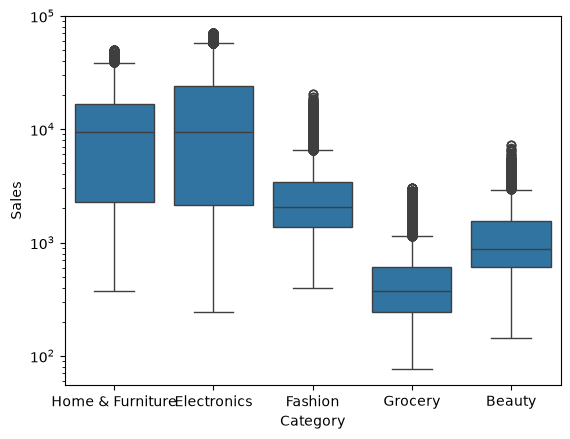

           Product_Name     Category  Quantity     Sales  Discount
2361   Laptops Model 11  Electronics         1  71145.42       0.0
3016   Laptops Model 11  Electronics         1  71145.42       0.0
4696   Laptops Model 11  Electronics         1  71145.42       0.0
6108   Laptops Model 11  Electronics         1  71145.42       0.0
7628   Laptops Model 11  Electronics         1  71145.42       0.0
10570  Laptops Model 11  Electronics         1  71145.42       0.0
11707  Laptops Model 11  Electronics         1  71145.42       0.0
12802  Laptops Model 11  Electronics         1  71145.42       0.0
13652  Laptops Model 11  Electronics         1  71145.42       0.0
13987  Laptops Model 11  Electronics         1  71145.42       0.0
Flagged outliers: 1307


In [173]:
print(df.groupby("Category")["Sales"].describe())

sns.boxplot(data=df, x="Category", y="Sales")
plt.yscale("log")
plt.show()

print(df.nlargest(10, "Sales")[["Product_Name", "Category", "Quantity", "Sales", "Discount"]])

# flag rows that are far above their category's normal range
q1 = df.groupby("Category")["Sales"].transform(lambda s: s.quantile(.25))
q3 = df.groupby("Category")["Sales"].transform(lambda s: s.quantile(.75))
df["Sales_Outlier"] = df["Sales"] > q3 + 3 * (q3 - q1)
print("Flagged outliers:", df["Sales_Outlier"].sum())

In [174]:
# time
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.strftime("%Y-%m")

# profitability
df["Profit_Margin"] = df["Profit"] / df["Sales"]
df["Shipping_Cost_Pct"] = df["Shipping_Cost"] / df["Sales"]
df["Is_Loss"] = (df["Profit"] < 0).astype(int)

# discount
df["Discount_Amount"] = df["Sales"] / (1 - df["Discount"]) * df["Discount"]
df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=[-0.001, 0, 0.10, 0.20, 0.30, 1.0],
    labels=["0%", "1-10%", "11-20%", "21-30%", ">30%"]
).astype(str)

# returns
df["Is_Returned"] = (df["Returned"] == "Yes").astype(int)
df["Returned_Revenue"] = df["Sales"] * df["Is_Returned"]

# order level
df["Order_Value"] = df.groupby("Order_ID")["Sales"].transform("sum")

# quick look at the main finding
g = df.groupby("Discount_Band")
print((g["Profit"].sum() / g["Sales"].sum()).round(3))

Discount_Band
0%        0.169
1-10%     0.123
11-20%    0.043
21-30%   -0.101
>30%     -0.353
dtype: float64


In [175]:
t = df.pivot_table(index="Category", columns="Discount_Band",
                   values=["Profit", "Sales"], aggfunc="sum")
margin = (t["Profit"] / t["Sales"]).round(3)
margin = margin[["0%", "1-10%", "11-20%", "21-30%", ">30%"]]
print(margin)
loss = df[df["Is_Loss"] == 1]
print("Loss-making rows:", len(loss), "of", len(df))
print("Total loss on those rows:", round(loss["Profit"].sum()))
print("Overall profit:", round(df["Profit"].sum()))
print(df.groupby("Discount_Band")["Is_Loss"].mean().round(3))

Discount_Band        0%  1-10%  11-20%  21-30%   >30%
Category                                             
Beauty            0.535  0.496   0.439   0.337  0.184
Electronics       0.129  0.057  -0.054  -0.240 -0.542
Fashion           0.427  0.379   0.304   0.183 -0.022
Grocery           0.041 -0.031  -0.154  -0.369 -0.763
Home & Furniture  0.185  0.118   0.014  -0.153 -0.443
Loss-making rows: 28881 of 97673
Total loss on those rows: -32117718
Overall profit: 34323583
Discount_Band
0%        0.210
1-10%     0.254
11-20%    0.290
21-30%    0.273
>30%      0.644
Name: Is_Loss, dtype: float64


In [176]:
assert df.isna().sum().sum() == 0, "nulls remain"
assert df.duplicated().sum() == 0, "duplicates remain"
assert df["Category"].nunique() == 5, "category spellings"
assert df["State"].nunique() == 14, "state spellings"
assert set(df["Returned"].unique()) == {"Yes", "No"}, "Returned labels"
assert (df["Quantity"] > 0).all() and (df["Sales"] > 0).all(), "invalid values"
assert df["Discount"].between(0, 1).all(), "discount out of range"
print("All checks passed.", len(df), "rows,", df.shape[1], "columns")

All checks passed. 97673 rows, 31 columns


In [177]:
df.to_csv("../data/ecommerce_clean.csv", index=False)

check = pd.read_csv("../data/ecommerce_clean.csv")
print(check.shape)

(97673, 31)


In [178]:
log = pd.DataFrame([
    ["Category spelling/spaces", "strip + title case", "15 spellings became 5"],
    ["State casing", "strip + title case", "28 became 14"],
    ["Returned labels Y/N", "mapped to Yes/No", "same labels"],
    ["Duplicate rows", "dropped", "exact copies inflate revenue"],
    ["Negative Quantity/Sales", "absolute value", "sign typo, cost and profit were normal"],
    ["Missing City", "filled from customer's other orders", "one city per customer"],
    ["Missing Payment_Mode", "filled from same order, else Unknown", "one payment per order"],
    ["Missing Discount", "recovered from product price", "avoid guessing"],
    ["Profit consistency", "0 mismatches", "no action"],
    ["Sales outliers", "flagged, kept", "large but plausible orders"],
], columns=["Problem", "Action", "Reason"])

log.to_csv("../data/cleaning_log.csv", index=False)
log

,Problem,Action,Reason
0,Category spelling/spaces,strip + title case,15 spellings became 5
1,State casing,strip + title case,28 became 14
2,Returned labels Y/N,mapped to Yes/No,same labels
3,Duplicate rows,dropped,exact copies inflate revenue
4,Negative Quantity/Sales,absolute value,"sign typo, cost and profit were normal"
5,Missing City,filled from customer's other orders,one city per customer
6,Missing Payment_Mode,"filled from same order, else Unknown",one payment per order
7,Missing Discount,recovered from product price,avoid guessing
8,Profit consistency,0 mismatches,no action
9,Sales outliers,"flagged, kept",large but plausible orders


In [179]:
print("ALL CHECK PASSES \n Cleaning Done")

ALL CHECK PASSES 
 Cleaning Done
